#### DESCRIPTION

Это набор транзакционных данных, содержащий все транзакции, совершенные в период с 01.12.2010 по 09.12.2011 зарегистрированной в Великобритании онлайн-компанией, не имеющей розничных магазинов. Компания в основном продает уникальные подарки на все случаи жизни. Многие клиенты компании — оптовые торговцы

Источник: https://archive.ics.uci.edu/dataset/352/online%2Bretail



| Переменная | Характеристика | Тип | Описание | Единицы | Пропущенные значения |
|---|---|---|---|---|---|
| InvoiceNo | ID | Categorical | 6-значный целочисленный номер, уникально присвоенный каждой транзакции. Если код начинается с буквы `c`, это означает отмену транзакции |  | no |
| StockCode | ID | Categorical | 5-значный целочисленный номер, уникально присвоенный каждому отдельному продукту |  | no |
| Description | Feature | Categorical | название продукта |  | no |
| Quantity | Feature | Integer | количество каждого продукта в транзакции |  | no |
| InvoiceDate | Feature | Date | дата и время создания каждой транзакции |  | no |
| UnitPrice | Feature | Continuous | цена продукта за единицу | sterling | no |
| CustomerID | Feature | Categorical | 5-значный целочисленный номер, уникально присвоенный каждому покупателю |  | no |
| Country | Feature | Categorical | название страны, в которой проживает каждый покупатель |  | no |

### Import library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy import stats

### Data preparation

In [2]:
loaded_data = pd.read_excel('data/Online Retail.xlsx')

In [3]:
df = loaded_data.copy()

display(df[df['UnitPrice'] == 0].head()) # В датасете есть записи с описаниями: NaN, check, damaged, destroyed, ??? и т.д., UnitPrice = 0. Для корректного анализа они были исключены из выборки
df = df[df['UnitPrice'] != 0]

df = df[~((df['StockCode'] == 'POST') | (df['StockCode'] == 'DOT'))] # Исключил записи о доставках

df = df[~( # Исключил записи о:
    (df['Description'].str.contains('gift', na=False)) | # Подарочных купонах
    (df['Description'].str.contains('CARRIAGE', na=False)) | # Перевозках
    (df['Description'].str.contains('AMAZON FEE', na=False)) | # Комиссии Амазон
    (df['Description'].str.contains('Manual', na=False)) | # Ручные записи, так как нет четкого понимания их проихождения. Это могут быть как продажи/отмены, так и корректировки цены, скидки из-за брака, акции и т.д.
    (df['Description'].str.contains('Discount', na=False)) | # Скидках
    (df['Description'].str.contains('Bank Charges', na=False)) | # Банковских комиссиях
    (df['Description'].str.contains('CRUK Commission', na=False)) | # Комиссиях британской благотворительности 
    (df['Description'].str.contains('SAMPLES', na=False)) # Образцах
)]

df = df[~df['InvoiceNo'].astype(str).str.contains('A')] # В датасете есть две записи о списании долгов, начинающихся с символа "А". Для корректного анализа исключил их

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


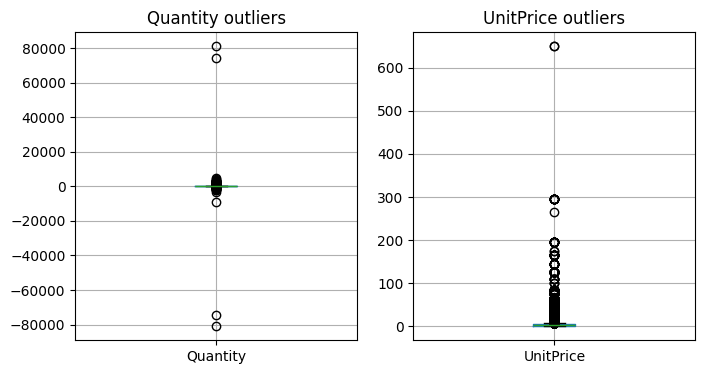

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom


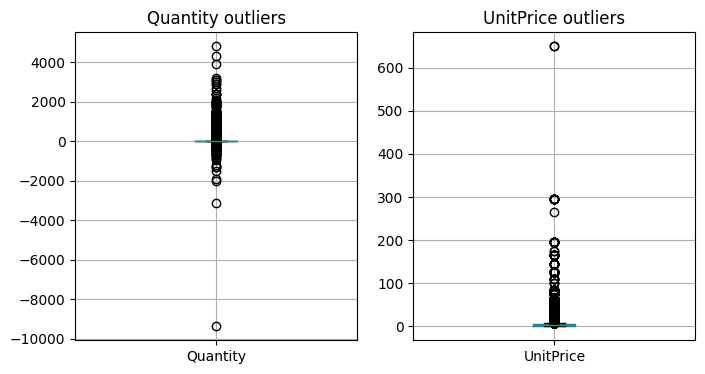

In [4]:
figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

df.boxplot(column='Quantity', ax=ax[0])
ax[0].set_title('Quantity outliers')

df.boxplot(column='UnitPrice', ax=ax[1])
ax[1].set_title('UnitPrice outliers')

plt.show()
# Выбросы в UnitPrice являются дорогими единичными или комплектными продуктами, поэтому заменять или удалять их нецелесообразно
# В Quantity есть 4 подозрительные записи, выглядящие неестественно на фоне остальных данных. Очень крупные покупки, которые были отменены менее чем через 20 минут
display(df[(df['Quantity'] > 10000) | (df['Quantity'] < -10000)])
df = df[~((df['Quantity'] > 10000) | (df['Quantity'] < -10000))] 


figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,4))

df.boxplot(column='Quantity', ax=ax[0])
ax[0].set_title('Quantity outliers')

df.boxplot(column='UnitPrice', ax=ax[1])
ax[1].set_title('UnitPrice outliers')

plt.show()
# С учетом того, что магазин специализируется на оптовых продажах, решил не исключать из анализа оставшиеся в Quantity выбросы 
# Также на графике очень сильно выделяется выброс с Quantity  -9700, но так как у этого клиента помимо этой отмены было 167 покупок, нельзя с уверенностью сказать что это аномалия и исключить запись из анализа

In [5]:
print(f'Date types: \n{df.dtypes}\n') 
print(f'Missing Values: \n{df.isna().sum()}\n')
print(f'Dataframe size: \n{df.shape}\n')
# Хотя в документации к датасету указано что пропущенных значений в нем нет, в столбце CustomerID значительная часть значений = NaN
# Удаление этих значений приведет к большой потере данных, а замена на рандомный ID к ошибочному анализу, так как нет уверенности в том, что это новые заказы, а не повторные

Date types: 
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing Values: 
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     131553
Country             0
dtype: int64

Dataframe size: 
(536362, 8)



In [6]:
df.insert(5, 'InvoiceTime', df['InvoiceDate'].dt.time)
df['InvoiceDate'] = df['InvoiceDate'].dt.date 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df["InvoiceTime"] = pd.to_datetime(df["InvoiceTime"], format="%H:%M:%S").dt.time # Для удобства разделил дату и время на две колонки
df['Revenue'] = df['Quantity'] * df['UnitPrice']

sales_df = df[~df['InvoiceNo'].astype(str).str.contains('C')].copy()
cancels_df = df[df['InvoiceNo'].astype(str).str.contains('C')].copy()
full_customerID_df = sales_df[~(sales_df['CustomerID'].isna())].copy()

In [7]:
def without_december_filter(df): # Так как данные за 12.2011 не полные, для корректного анализа в части случаев потребуется исключить декабрь из анализа
    filtered_df = df[~((df['InvoiceDate'].dt.month == 12) & (df['InvoiceDate'].dt.year == 2011))].copy()
    return filtered_df

### Dynamic analysis

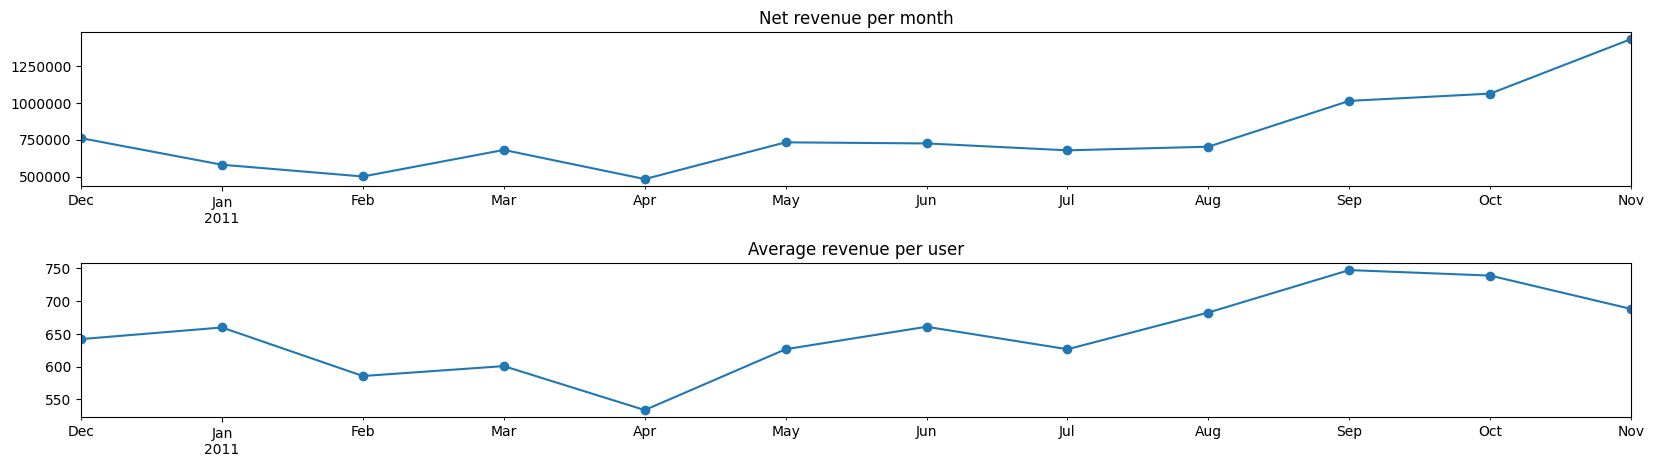

In [8]:
net_revenue = without_december_filter(df).set_index('InvoiceDate').resample('ME') # Чистая выручка в динамике по месяцам
group_for_arpu = without_december_filter(full_customerID_df).set_index('InvoiceDate').resample('ME')
arpu = group_for_arpu['Revenue'].sum() / group_for_arpu['CustomerID'].nunique() # Средняя выручка на пользователя

figure, ax = plt.subplots(figsize=(20, 12), nrows=2, ncols=1)

net_revenue['Revenue'].sum().plot(figsize=(20, 5), kind='line', marker='o', ax=ax[0])
arpu.plot(figsize=(20, 5), kind='line', marker='o', ax=ax[1])

ax[0].ticklabel_format(style='plain', axis='y')
ax[0].set_title('Net revenue per month')
ax[0].set_xlabel('')

ax[1].set_title('Average revenue per user')
ax[1].set_xlabel('')

plt.subplots_adjust(hspace=0.5) 
plt.show()

In [33]:
df.InvoiceDate.min()

Timestamp('2010-12-01 00:00:00')

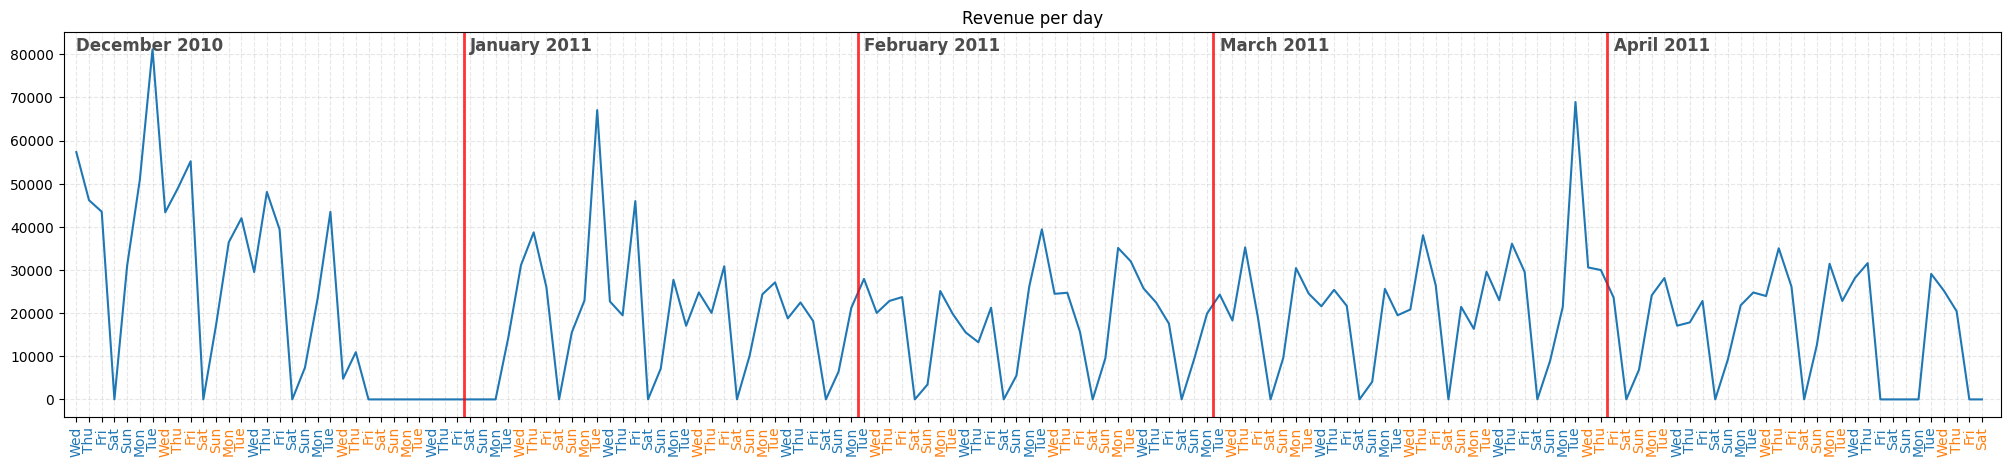

In [35]:
days = ['Wed', 'Thu', 'Fri', 'Sat', 'Sun', 'Mon', 'Tue']
week_colors = ['#1f77b4', '#ff7f0e'] 
daily_revenue = without_december_filter(df).set_index('InvoiceDate').resample('D')['Revenue'].sum().to_frame()
daily_revenue['Day_Name'] = [days[i % 7] for i in range(len(daily_revenue))] # Группировка по дням недели. Первый день отчетного периода - 2010-12-01, среда

daily_revenue_slice = daily_revenue.head(151).copy() # Срез 5 месяцев
daily_revenue_slice['Month_Name'] = daily_revenue_slice.index.strftime('%B %Y') 

ax = daily_revenue_slice.plot(kind='line', x='Day_Name', y='Revenue', legend=False, figsize=(25, 5))
ax.set_xticks(range(len(daily_revenue_slice)))
ax.set_xticklabels(daily_revenue_slice['Day_Name'], rotation=90)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlim(-1, len(daily_revenue_slice) + 0.5)
ax.set_xlabel('')
ax.set_title('Revenue per day')

for i, label in enumerate(ax.get_xticklabels()): # Чередующиеся цвета, для разделения недель
    week_index = i // 7
    color = week_colors[week_index % len(week_colors)]
    label.set_color(color)

current_month = daily_revenue_slice['Month_Name'].iloc[0]
ax.text(0, ax.get_ylim()[1] * 0.95, current_month, fontsize=12, fontweight='bold', alpha=0.7) # Первый месяц

for idx in range(1, len(daily_revenue_slice)): # Разделение по месяцам, для удобства анализа
    if daily_revenue_slice['Month_Name'].iloc[idx] != current_month:
        current_month = daily_revenue_slice['Month_Name'].iloc[idx]
        ax.axvline(x=idx - 0.5, color='red', linestyle='-', linewidth=2, alpha=0.8)
        ax.text(idx, ax.get_ylim()[1] * 0.95, current_month, fontsize=12, fontweight='bold', alpha=0.7)

plt.show()    

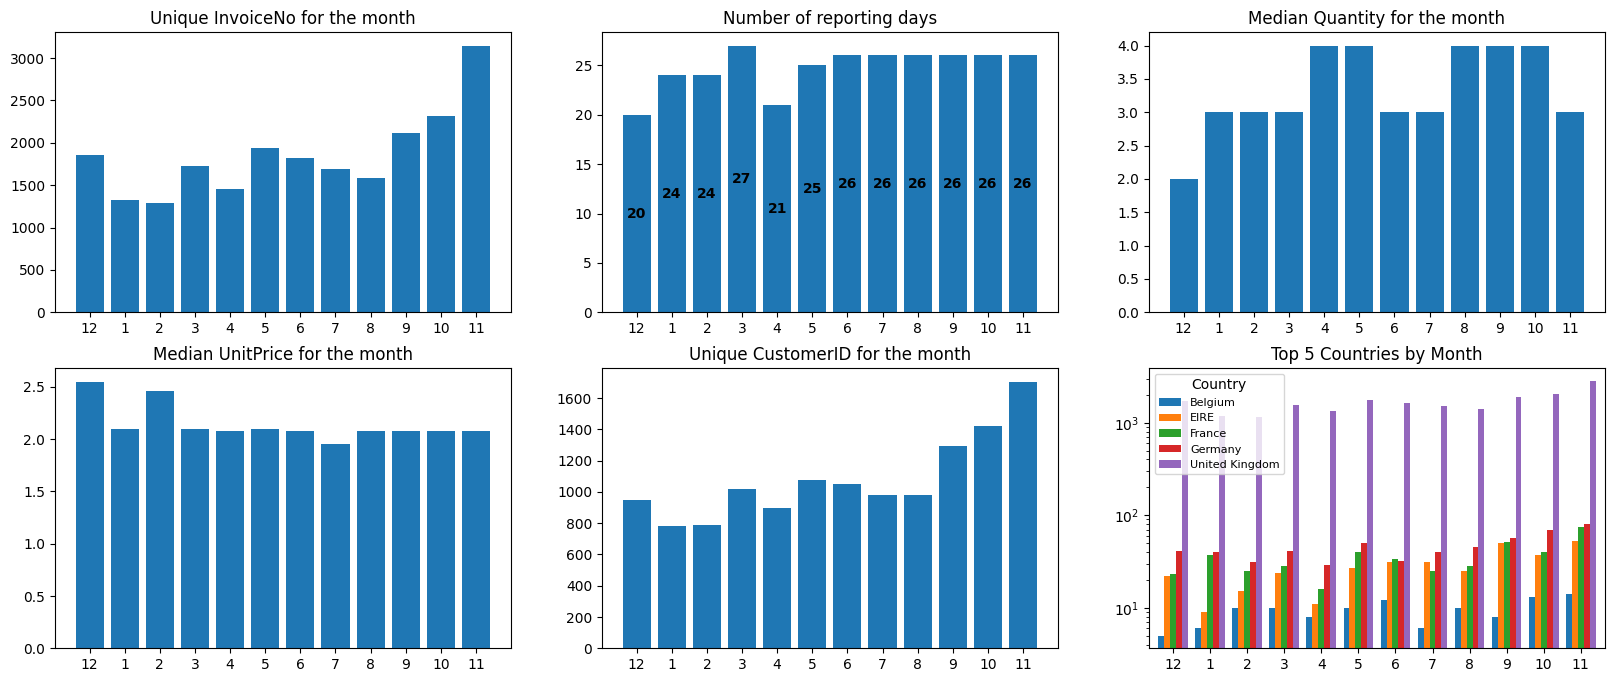

In [ ]:
transactions = without_december_filter(df)
transactions['Month'] = transactions['InvoiceDate'].dt.to_period('M')
unique_orders = transactions.drop_duplicates(subset=['InvoiceNo', 'Country'])

top_5_country_names = unique_orders['Country'].value_counts().head(5).index # Названия пяти самых популярных стран
top_5_country_data = unique_orders[unique_orders['Country'].isin(top_5_country_names)]
country_group = top_5_country_data.groupby(['Month', 'Country']).size().unstack(fill_value=0)
country_group.index = country_group.index.month

months_data = transactions.groupby('Month').agg(
    invoice_unq = ('InvoiceNo', 'nunique'),
    reporting_days  = ('InvoiceDate', lambda x: x.dt.date.nunique()),
    quantity_median = ('Quantity', 'median'), # Есть выбросы, поэтому использовал median
    unit_price_median = ('UnitPrice', 'median'), # Есть выбросы, поэтому использовал median
    customer_unq = ('CustomerID', 'nunique')
)
month_labels = months_data.index.month.astype(str) # Подписи в формате месяцев

figure, ax = plt.subplots(figsize=(20, 8), nrows=2, ncols=3)
ax[0, 0].bar(month_labels, months_data.invoice_unq)
ax[0, 0].set_title('Unique InvoiceNo for the month')

days_bar = ax[0, 1].bar(month_labels, months_data.reporting_days)
ax[0, 1].set_title('Number of reporting days')
ax[0, 1].bar_label(days_bar, label_type='center', fontweight='bold')

ax[0, 2].bar(month_labels, months_data.quantity_median)
ax[0, 2].set_title('Median Quantity for the month')

ax[1, 0].bar(month_labels, months_data.unit_price_median)
ax[1, 0].set_title('Median UnitPrice for the month')

ax[1, 1].bar(month_labels, months_data.customer_unq)
ax[1, 1].set_title('Unique CustomerID for the month')

country_group.index = country_group.index.astype(str)
country_group.plot(kind='bar', ax=ax[1, 2], width=0.8, logy=True, rot=0)
ax[1, 2].set_xlabel('')
ax[1, 2].set_title('Top 5 Countries by Month')
ax[1, 2].legend(title='Country', fontsize=8, loc='upper left')

plt.show()

# Суббота - выходной день
# Можно заметить, что четверг чаще остальных является самым прибыльным днем недели, из чего можно сделать вывод о некоторой еженедельной сезонности

# Падение общей месячной выручки и средней выручки на пользователя в апреле связана с наименьшим количеством отчетных дней
# Падение выручки в феврале, скорее всего, связано с охлаждением рынка после праздников. Так как есть заметное снижение уникальных количества заказов и уникальных клиентов. Но для точного выявления причины данных недостаточно
# Также в апреле можно заметить меньшее количество заказов из других стран, по сравнению с остальными месяцами
# Начиная с августа выручка растет, что позволяет сделать предположение о предновогодней сезонности продаж или о сезоне back to school
# ARPU растет не так значительно, плюс падает в октябре, но вместе с тем, начиная с августа, растет уникальное число месячных пользователей и количество уникальных заказов, что объясняет общий рост выручки


### Сustomer analysis

In [11]:
cohort_df = without_december_filter(full_customerID_df)
cohort_df['InvoiceDate'] = cohort_df['InvoiceDate'].dt.to_period('M') # Месяц и год покупки
cohort_df['CohortMonth'] = cohort_df.groupby('CustomerID')['InvoiceDate'].transform('min') # Первый месяц покупки клиента
cohort_df['CohortIndex'] = (cohort_df['InvoiceDate'].dt.year - cohort_df['CohortMonth'].dt.year) * 12 + (cohort_df['InvoiceDate'].dt.month - cohort_df['CohortMonth'].dt.month) # Номер месяца жизни когорты

cohort_data = cohort_df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index() # Количество уникальных клиентов из каждой когорты, совершивших покупки в каждый месяц
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID') # Сводная таблица с численностью когорт
cohort_sizes = cohort_counts.iloc[:, 0] # Размеры каждой когорты в нулевой период, для вычисления процентного соотношения
retention = cohort_counts.divide(cohort_sizes, axis=0) # Retention rate, рассчитанный относительно нулевого периода
retention 

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortMonth,,,,,,,,,,,,
2010-12,1.0,0.365385,0.323529,0.383484,0.361991,0.398190,0.361991,0.348416,0.352941,0.394796,0.373303,0.502262
2011-01,1.0,0.219277,0.267470,0.228916,0.318072,0.289157,0.248193,0.240964,0.296386,0.327711,0.366265,NaN
2011-02,1.0,0.186842,0.186842,0.286842,0.271053,0.244737,0.255263,0.273684,0.247368,0.305263,NaN,NaN
2011-03,1.0,0.148230,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,NaN,NaN,NaN
2011-04,1.0,0.210000,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,NaN,NaN,NaN,NaN
2011-05,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.173554,0.157025,0.264463,0.231405,0.330579,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.176471,0.203209,0.224599,0.272727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.201183,0.242604,0.242604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


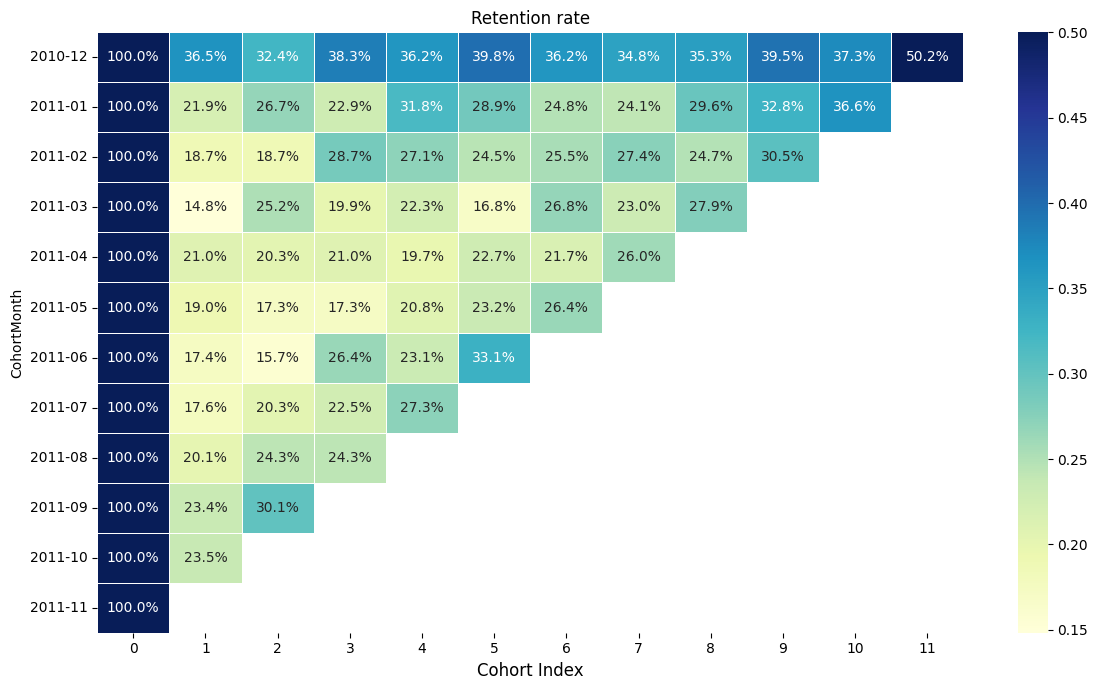

In [12]:
plot_data = retention.copy()
plot_data.index = plot_data.index.astype(str)

plt.figure(figsize=(12, 7))
sns.heatmap(
    plot_data,
    annot=True,
    fmt='.1%',  
    cmap='YlGnBu',  
    vmax=0.5,  
    linewidths=0.5,
) # Тепловая карта когортного анализа

plt.xlabel('Cohort Index', fontsize=12)
plt.title('Retention rate')

plt.tight_layout()
plt.show()

# Наиболее стабильна в плане удержания первая когорта (2010-12). При этом стоит отметить, что клиенты этой когорты не обязательно являются новыми клиентами, так как данных о предыдущих отчетных периодах нет 
# Поэтому есть вероятность того, что в этой когорте уже сформировалась группа постоянных лояльных клиентов

# Все когорты теряют ~75-85% аудитории на второй месяц жизни. 
# За исключением 2011-04 и 2011-05 на третий-четвертый месяц жизни наблюдается некоторый рост retention, из чего можно сделать предположение о том, что часть клиентов совершает покупки раз в 2-4 месяца 

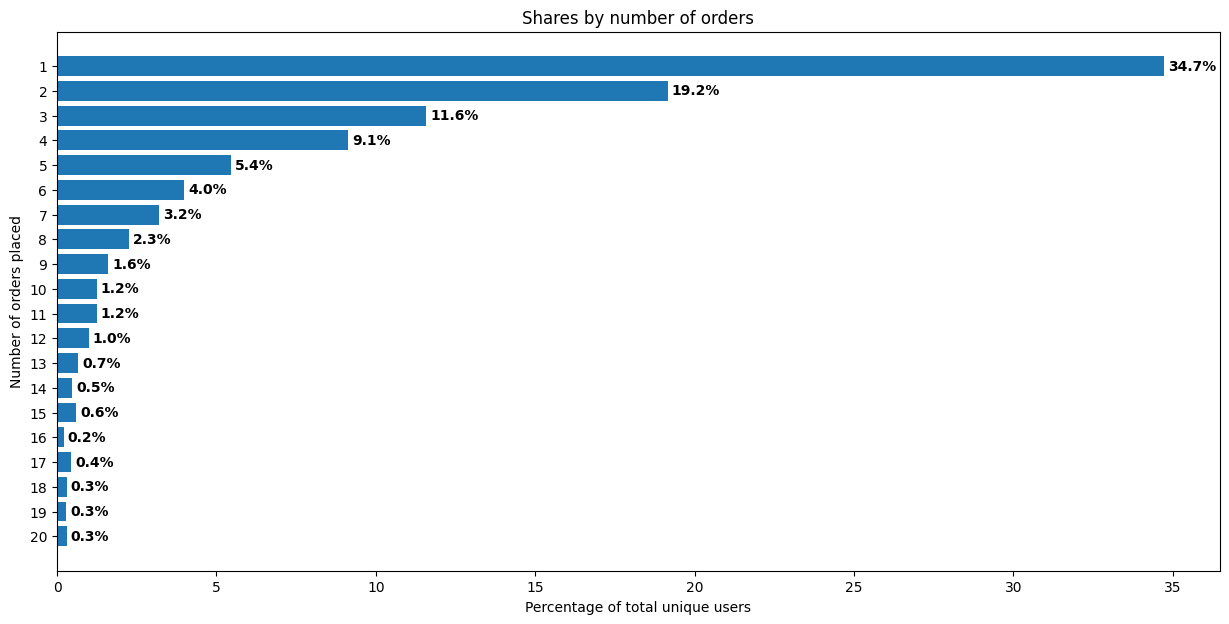

In [13]:
unq_customer_count = full_customerID_df['CustomerID'].nunique() 

unq_orders = full_customerID_df.groupby('CustomerID')['InvoiceNo'].nunique()
unq_order_counts = unq_orders.value_counts().sort_index(ascending=False).tail(20)

plt.figure(figsize=(15, 7))
distribution_of_orders = plt.barh(unq_order_counts.index.astype(str), (unq_order_counts.values / unq_customer_count) * 100)
plt.bar_label(distribution_of_orders, fmt='%.1f%%', padding=3, fontweight='bold')
plt.xlabel('Percentage of total unique users')
plt.ylabel('Number of orders placed')
plt.title('Shares by number of orders')

plt.show()

# ~65% клиентов делали как минимум один повторный заказ ~35% клиентов совершили только один заказ за весь отчетный период

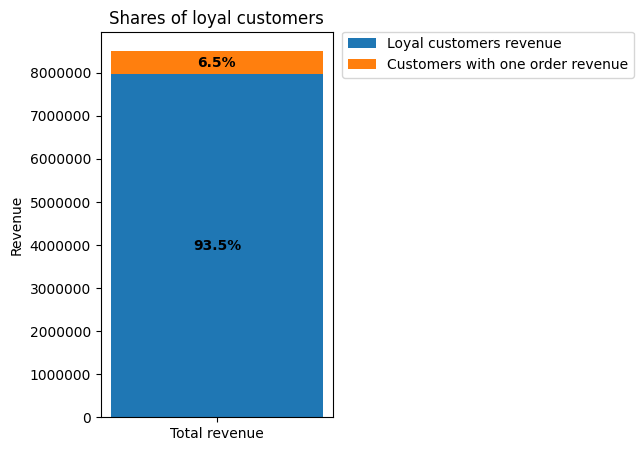

In [14]:
customer_revenue = full_customerID_df.groupby('CustomerID').agg(
    unq_invoices = ('InvoiceNo', 'nunique'),
    total_revenue = ('Revenue', 'sum')
)

loyal_customers = customer_revenue[customer_revenue['unq_invoices'] > 1]
loyal_customers_revenue = loyal_customers['total_revenue'].sum()
total_customer_revenue = customer_revenue['total_revenue'].sum()
one_order_customers_revenue = total_customer_revenue - loyal_customers_revenue # Выручка с клиентов, совершивших одну покупку
pct_loyal = (loyal_customers_revenue / total_customer_revenue) * 100 # Доля лояльных клиентов
pct_one_order = (one_order_customers_revenue / total_customer_revenue) * 100 # Доля клиентов с одной покупкой

plt.figure(figsize=(3, 5))
loyal_bar = plt.bar(x=['Total revenue'], height=[loyal_customers_revenue], label='Loyal customers revenue')
one_order_bar = plt.bar(x=['Total revenue'], height=[one_order_customers_revenue], bottom=[loyal_customers_revenue], label='Customers with one order revenue')
plt.bar_label(loyal_bar, labels=[f'{pct_loyal:.1f}%'], label_type='center', fontweight='bold')
plt.bar_label(one_order_bar, labels=[f'{pct_one_order:.1f}%'], label_type='center', fontweight='bold')

plt.ticklabel_format(style='plain', axis='y')
plt.ylabel('Revenue')
plt.title('Shares of loyal customers')
plt.legend(bbox_to_anchor=(1.01, 1.02), loc='upper left')
plt.show()

# Клиенты, совершившие один заказ приносят лишь 6.5% от общей выручки
# Для повышения прибыли компании стоит проанализировать ее способы взаимодействия с клиентами. 
# С учетом того, что разовых клиентов около 35%, работа с такими клиентами и перевод их в категорию лояльных может значительно повысить общую выручку

In [15]:
median_revenue_per_customer = full_customerID_df.groupby('CustomerID')['Revenue'].sum().median()

sales_without_duplicates = full_customerID_df[['CustomerID', 'InvoiceNo', 'InvoiceDate']].drop_duplicates()
sales_without_duplicates = sales_without_duplicates.sort_values(by=['CustomerID', 'InvoiceDate'])
sales_without_duplicates['TimeDifference'] = sales_without_duplicates.groupby('CustomerID')['InvoiceDate'].diff()
filtered_gaps = sales_without_duplicates['TimeDifference'].dropna()
filtered_gaps = filtered_gaps[filtered_gaps.values > 0]

median_gap_between_purchases = filtered_gaps.median()
mode_gap_between_purchases = filtered_gaps.mode()[0]
min_gap_between_purchases = filtered_gaps.min()
max_gap_between_purchases = filtered_gaps.max()

print(f'Median gap between purchases: {median_gap_between_purchases.days} days')
print(f'Mode gap between purchases: {mode_gap_between_purchases.days} days')
print(f'Min gap between purchases: {min_gap_between_purchases.days} days')
print(f'Max gap between purchases: {max_gap_between_purchases.days} days')

print(f'\nMedian revenue per customer: {round(median_revenue_per_customer, 2)}')

# Чаще всего, клиенты совершают покупки с периодичностью 7 дней. Частично это можно было наблюдать на графике ежедневной выручки, но четкой тенденции покупок в конкретный день недели не прослеживается 

Median gap between purchases: 28 days
Mode gap between purchases: 7 days
Min gap between purchases: 1 days
Max gap between purchases: 366 days

Median revenue per customer: 668.04


### RFM

In [16]:
last_date = full_customerID_df['InvoiceDate'].max() + pd.Timedelta(days=1) # Максимальная InvoiceDate + 1 день, для корректности расчетов
rfm_grouped = full_customerID_df.groupby('CustomerID').agg(
    recency = ('InvoiceDate', lambda x: (last_date - x.max()).days),
    frequency = ('InvoiceNo', 'nunique'),
    monetary = ('Revenue', 'sum')
)

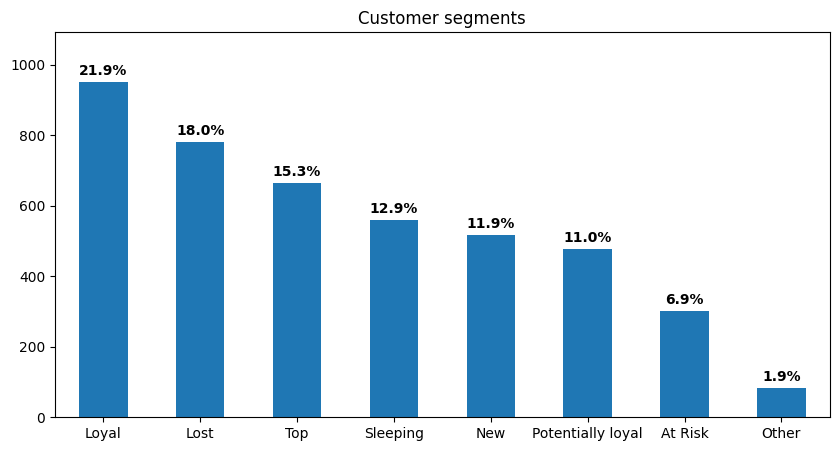

In [17]:
rfm_grouped['R_score'] = pd.qcut(rfm_grouped['recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm_grouped['M_score'] = pd.qcut(rfm_grouped['monetary'], q=5, labels=[1, 2, 3, 4, 5]) 
frequency_bins = [0, 1, 2, 5, 10, float('inf')]
rfm_grouped['F_score'] = pd.cut(rfm_grouped['frequency'], bins=frequency_bins, labels=[1, 2, 3, 4, 5]).astype(int)



rfm_grouped[['R_score', 'F_score', 'M_score']] = rfm_grouped[['R_score', 'F_score', 'M_score']].astype(int)
rfm_grouped['rfm_grouped_sum'] = rfm_grouped['R_score'] + rfm_grouped['F_score'] + rfm_grouped['M_score']


def calc_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Top'

    elif r >= 3 and f >= 3:
        return 'Loyal'

    elif r >= 4 and f <= 2:
        return 'New'

    elif r == 3 and f <= 2: # Были покупки недавно, но всего покупок мало
        return 'Potentially loyal'
    
    elif r == 2 and f >= 3:
        return 'At Risk' # Раньше покупали часто, но последняя покупка была давно

    elif r == 2 and f <= 2:
        return 'Sleeping' # Покупали раньше, но давно не было покупок
    
    elif r == 1 and f <= 2:
        return 'Lost' # Мало покупок, последняя покупка была совершена давно
    
    else:
        return 'Other'

rfm_grouped['segment'] = rfm_grouped.apply(calc_segment, axis=1)

plt.figure(figsize=(10, 5))
segments_grouped = rfm_grouped.groupby('segment')['segment'].count().sort_values(ascending=False)
total_customers = segments_grouped.sum()
labels = [f'{count / total_customers:.1%}' for count in segments_grouped]

segment_ax = segments_grouped.plot(kind='bar', rot=0)
segment_ax.bar_label(segment_ax.containers[0], labels=labels, padding=3, fontsize=10, weight='bold')
segment_ax.set_xlabel('')
segment_ax.margins(y=0.15) 
plt.title('Customer segments')
plt.show()

# Самый большой сегмент клиентов - лояльные клиенты. Также можно заметить большое количество ТОП-клиентов. Эти два сегмента в совокупности приносят основную долю выручки
# Доля потерянных клиентов является второй по величине, из чего можно сделать предположение, что у компании слабая система работы с клиентами находящимися в зоне риска
# Значительная часть клиентов попала в сегмент спящих, но с условием имеющейся предновогодней сезонности, нельзя с уверенностью сказать что это потенциально потерянные клиенты

### Clustering

In [18]:
last_date = full_customerID_df['InvoiceDate'].max() + pd.Timedelta(days=1)

clustering_df = full_customerID_df.groupby('CustomerID').agg(
    recency = ('InvoiceDate', lambda x: (last_date - x.max()).days),
    frequency = ('InvoiceNo', 'nunique'),
    monetary = ('Revenue', 'sum'),
    quantity=('Quantity', 'sum')
) # Данные для кластеризации на основе основного датасета

clustering_df['avg_check'] = clustering_df['monetary'] / clustering_df['frequency']
clustering_df['items_per_order'] = clustering_df['quantity'] / clustering_df['frequency']
clustering_df = clustering_df.drop(columns='quantity') # Дополнительные фичи

clustering_df_log = np.log(clustering_df)

In [19]:
clustering_df_scaled = StandardScaler().fit_transform(clustering_df_log)
tsne_array = TSNE(n_components=2, random_state=42).fit_transform(clustering_df_scaled)

In [20]:
inertia = []
silhouette = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42).fit(clustering_df_scaled)
    preds = kmeans.predict(clustering_df_scaled)
    inertia.append(np.sqrt(kmeans.inertia_))
    silhouette.append(silhouette_score(clustering_df_scaled, preds))

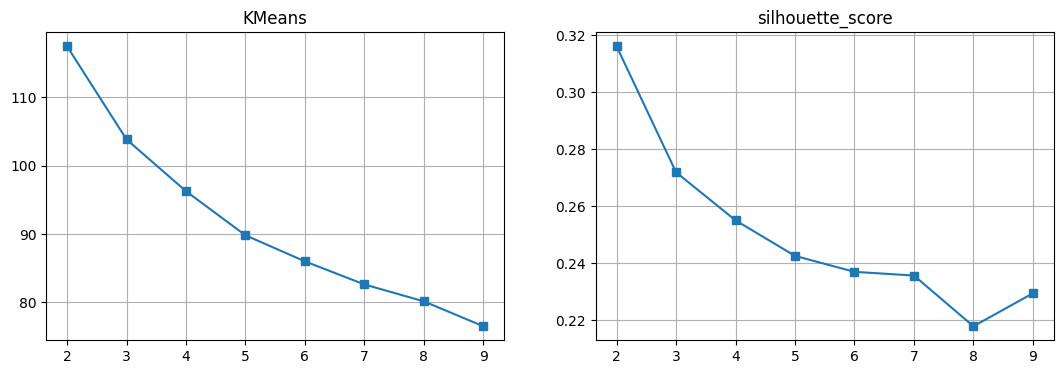

In [21]:
figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(13, 4))
ax[0].plot(np.arange(2, 10), inertia, marker='s')
ax[0].grid(True)
ax[0].set_xticks(np.arange(2, 10))
ax[0].set_title('KMeans')

ax[1].plot(np.arange(2, 10), silhouette, marker='s')
ax[1].grid(True)
ax[1].set_xticks(np.arange(2, 10))
ax[1].set_title('silhouette_score')

plt.show()

# Судя по silhouette_score оптимальное число кластеров = 2, но в этом случае все клиенты будут разделены на тех, кто периодически покупает на большие суммы и тех, кто купил 1-2 раза на небольшую сумму
# На графике KMeans нет явных изломов, но можно отметить небольшое замедление темпов снижения ошибки на при 3 и 5 кластеров
# Так как при 5 кластерах происходило значительное смешение, в качестве оптимального значения было выбрано 3 кластера, чтобы не терять уникальность портретов клиентов

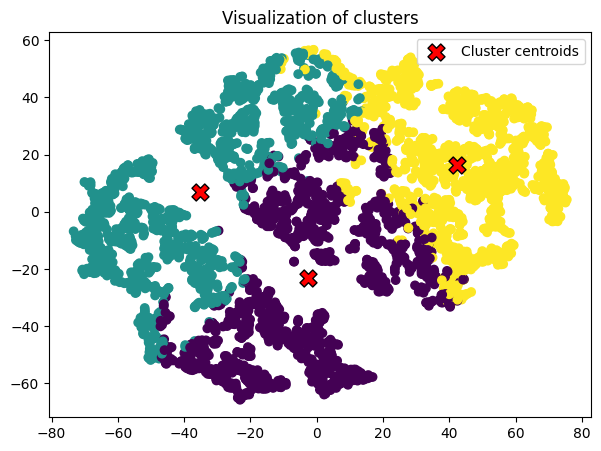

In [22]:
kmeans_tsne = KMeans(n_clusters=3, random_state=42).fit(clustering_df_scaled)
labels_tsne = kmeans_tsne.labels_

tsne_centers = np.array([tsne_array[labels_tsne == cluster].mean(axis=0) for cluster in np.unique(labels_tsne)])

plt.figure(figsize=(7, 5))
plt.scatter(tsne_array[:, 0], tsne_array[:, 1], c=labels_tsne)
plt.scatter(tsne_centers[:, 0], tsne_centers[:, 1], marker='X', s=150, c='red', edgecolor='black', label='Cluster centroids')
plt.title('Visualization of clusters')
plt.legend()
plt.show()

In [23]:
total_revenue = clustering_df['monetary'].sum()
clustering_df['cluster'] = kmeans_tsne.labels_ # Добавление меток кластеров к клиентам

cluster_profile = clustering_df.groupby('cluster').agg( # Группировка по кластерам
    recency = ('recency', 'median'),
    frequency = ('frequency', 'median'),
    monetary = ('monetary', 'median'),
    avg_check = ('avg_check', 'median'),
    items_per_order = ('items_per_order', 'median'),
    revenue_share=('monetary', lambda x: round((x.sum() / total_revenue) * 100, 1)),
    size = ('cluster', 'size')
)

cluster_profile

# Кластер 0. Спящие клиенты. Купили > 1 раза, но последняя покупка была давно
# Кластер 1. Случайные/разовые клиенты. Сделали одну покупку, с небольшим чеком и объемом
# Кластер 2. Лояльные клиенты. Покупают часто, в больших объемах и приносят основную долю выручки

# Кластеры 0 и 1 по размерам сопоставимы с кластером 2, активная работа с ними и перевод в кластер 2 может принести значительное увеличение выручки 
# Для формирования релевантных рекомендаций важно понимать, какие методы коммуникации с клиентами налажены сейчас и существуют ли они вообще

# В контексте оптового ритейла, кластер 0 по своим характеристикам похож на два типа клиентов: тех, кто покупает много, но редко, либо тех, кто покупали, но нашли более выгодные условия у конкурентов 
# В обоих случаях можно попробовать "пробудить" их скидками на повторный заказ

# Кластер 1 по характеристикам похож на клиентов, ищущих наиболее выгодный вариант для постоянного сотрудничества - в их случае выигрышным методом взаимодействия может быть хорошо спланированная система лояльности

,recency,frequency,monetary,avg_check,items_per_order,revenue_share,size
cluster,,,,,,,
0,80.0,2.0,674.68,386.420000,246.50,17.1,1545
1,95.0,1.0,216.30,151.420000,76.50,4.7,1449
2,13.0,7.0,2314.65,341.526667,199.75,78.2,1339


### Product analysis

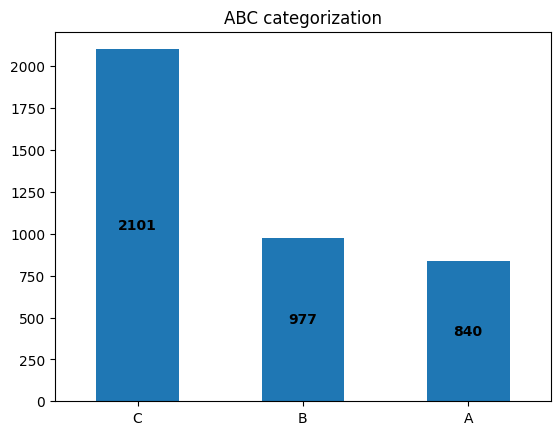

,description,revenue,num_sales,revenue_share,cumulative_share,ABC_category
StockCode,,,,,,
22423,REGENCY CAKESTAND 3 TIER,164762.19,13022,1.68,1.68,A
47566,PARTY BUNTING,98302.98,18018,1.00,2.69,A
85123A,WHITE HANGING HEART T-LIGHT HOLDER,97894.50,35082,1.00,3.69,A
85099B,JUMBO BAG RED RETROSPOT,92356.03,47359,0.94,4.63,A
23084,RABBIT NIGHT LIGHT,66756.59,30680,0.68,5.31,A
22086,PAPER CHAIN KIT 50'S CHRISTMAS,63791.94,18902,0.65,5.96,A
84879,ASSORTED COLOUR BIRD ORNAMENT,58959.73,36381,0.60,6.57,A
79321,CHILLI LIGHTS,53768.06,10226,0.55,7.11,A
22502,PICNIC BASKET WICKER SMALL,51041.37,1865,0.52,7.64,A


In [24]:
product_df = df.copy()

product_grouped = product_df.groupby('StockCode').agg(
    description = ('Description', 'first'),
    revenue = ('Revenue', 'sum'),
    num_sales = ('Quantity', 'sum')
)
product_grouped = product_grouped.sort_values(by='revenue', ascending=False)
total_revenue = product_grouped['revenue'].sum()

product_grouped['revenue_share'] = product_grouped['revenue'] / total_revenue # Доля выручки товара от общей выручки
product_grouped['cumulative_share'] = product_grouped['revenue_share'].cumsum() # Накопительная доля товара и всех товаров, идущих выше него

def calc_category(share):
    if share <= 0.80: # Накопительная доля до 80%
        return 'A'
    elif share <= 0.95: # Накопительная доля до 95%
        return 'B'
    else:
        return 'C' # Накопительная доля > 95%

product_grouped['ABC_category'] = product_grouped['cumulative_share'].apply(calc_category)
product_grouped['cumulative_share'] = round(product_grouped['cumulative_share'] * 100, 2)
product_grouped['revenue_share'] = round(product_grouped['revenue_share'] * 100, 2)

abc_val_counts = product_grouped['ABC_category'].value_counts()
abc_ax = abc_val_counts.plot(kind='bar', rot=0)
abc_ax.bar_label(abc_ax.containers[0], label_type='center', fontsize=10, weight='bold')
plt.title('ABC categorization')
plt.xlabel('')
plt.show()

product_grouped.head(10)

# Большинство товаров приносят минимум выручки - категория С в два раза больше категорий А и В вместе взятых, но при этом все эти товары генерируют только 5% от всей выручки
# Стоит дополнительно проанализировать маржинальность товаров категории С

### Cancelled orders

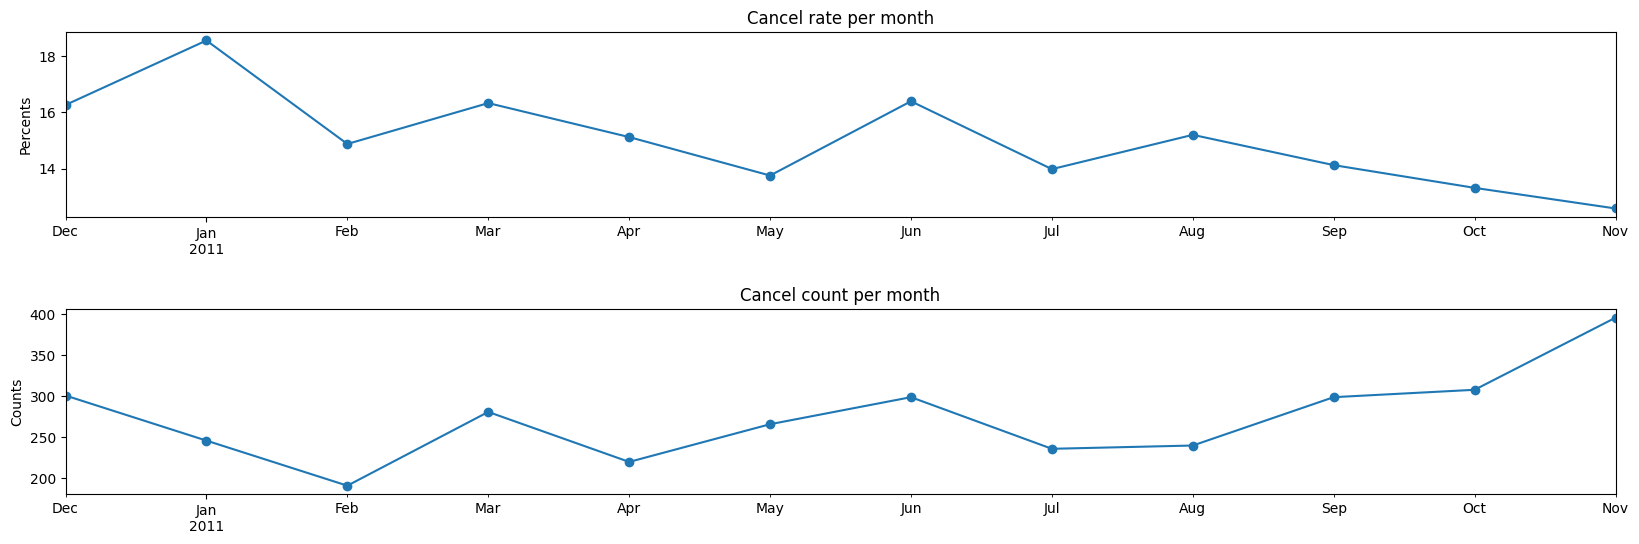

In [25]:
cancels_without_december = without_december_filter(cancels_df)

successful_orders = without_december_filter(sales_df).set_index('InvoiceDate').resample('ME')['InvoiceNo'].nunique()
cancelled_orders = cancels_without_december.set_index('InvoiceDate').resample('ME')['InvoiceNo'].nunique()
cancel_rate = cancelled_orders / (successful_orders + cancelled_orders) * 100

figure, ax = plt.subplots(figsize=(20, 6), nrows=2, ncols=1)
cancel_rate.plot(kind='line', marker='o', ax=ax[0])
ax[0].ticklabel_format(style='plain', axis='y')
ax[0].set_title('Cancel rate per month')
ax[0].set_xlabel('')
ax[0].set_ylabel('Percents')

cancelled_orders.plot(kind='line', marker='o', ax=ax[1])
ax[1].set_title('Cancel count per month')
ax[1].set_xlabel('')
ax[1].set_ylabel('Counts')

plt.subplots_adjust(hspace=0.5) 
plt.show()

# Доля отмен достигает максимума в январе 2011, затем постепенно снижается в течении года и достигает минимума в ноябре
# Но более информативен в данном случае график количества отмен - он коррелирует с графиком количества заказов в месяц и графиком количества уникальных пользователей
# Из этого можно сделать вывод, что здесь имеет место быть классическая проблема масштабирования - чем больше заказов, тем больше отмен

Rate of cancelled orders for year: 14.76%
Rate of cancelled revenue for year: 2.43%


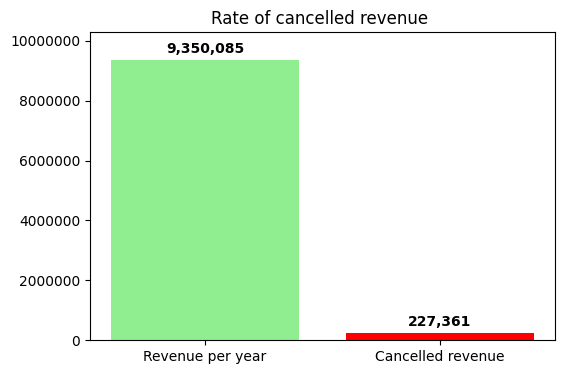

In [26]:
cancelled_revenue = abs(round(without_december_filter(cancels_df)['Revenue'].sum(), 2))
yearly_revenue = round(without_december_filter(df)['Revenue'].sum(), 2)

print(f'Rate of cancelled orders for year: {round(without_december_filter(cancels_df)['InvoiceNo'].nunique() / without_december_filter(df)['InvoiceNo'].nunique() * 100, 2)}%')
print(f'Rate of cancelled revenue for year: {round(cancelled_revenue / yearly_revenue * 100, 2)}%')

figure, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Revenue per year', 'Cancelled revenue'], [yearly_revenue, cancelled_revenue], color=['lightgreen', 'red'])
ax.bar_label(bars, padding=3, fmt='{:,.0f}', fontweight='bold')
ax.margins(y=0.1) 
plt.title('Rate of cancelled revenue ')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

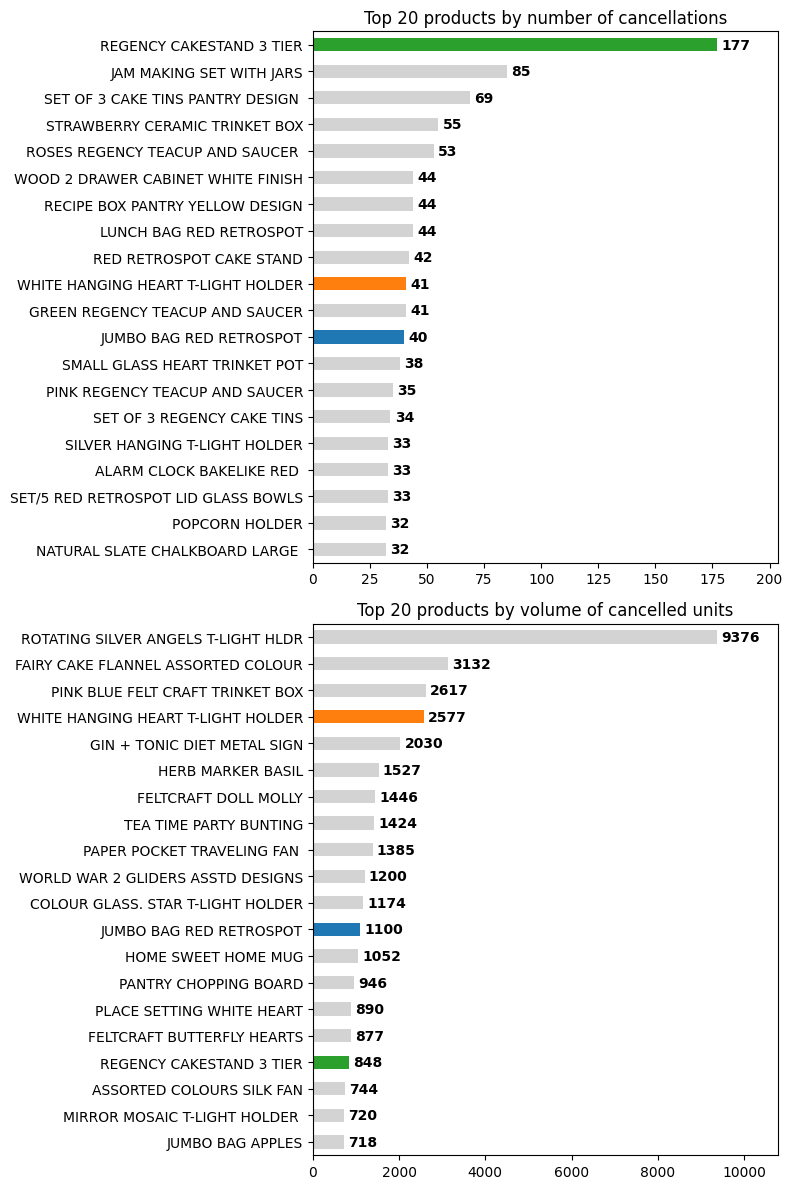

In [27]:
cancelled_orders_count = without_december_filter(cancels_df).groupby('Description')['InvoiceNo'].count().sort_values().tail(20)
cancelled_quantity_total = without_december_filter(cancels_df).groupby('Description')['Quantity'].sum().abs().sort_values().tail(20)

common = set(cancelled_orders_count.index) & set(cancelled_quantity_total.index) # Пересечения двух групп отмененных заказов
colors = plt.cm.tab10(range(len(common)))
color_map = dict(zip(common, colors)) # Генерация уникальных цветов, для выделения пересекающихся товаров
get_color = lambda x: color_map.get(x, '#d3d3d3') # Цвет для непересекающихся товаров

figure, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 12))

cancelled_orders_count.plot(kind='barh', ax=ax[0], color=cancelled_orders_count.index.map(get_color))
ax[0].set_title('Top 20 products by number of cancellations')
ax[0].bar_label(ax[0].containers[0], padding=3, fontweight='bold')
ax[0].set_xlim(0, cancelled_orders_count.max() * 1.15)
ax[0].set_ylabel('')

cancelled_quantity_total.plot(kind='barh', ax=ax[1], color=cancelled_quantity_total.index.map(get_color))
ax[1].set_title('Top 20 products by volume of cancelled units')
ax[1].bar_label(ax[1].containers[0], padding=3, fontweight='bold')
ax[1].set_xlim(0, cancelled_quantity_total.max() * 1.15)
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

# По количеству отмен сильно выделяется один товар: REGENCY CAKESTAND 3 TIER, он имеет наибольший разрыв с предыдущим значением
# В целом, по количеству отмен нельзя выделить явные товары аутсайдеры

# По количеству отмененных единиц товара сильно выделяется первый - общий объем отмены в три раза больше предыдущего значения. При этом практически весь объем был отменен в рамках одного заказа
# Из топ 20 товаров, отмененных по объему, у 12 большая часть объема была отменена в рамках одного заказа, что позволяет выдвинуть гипотезу о том, что как минимум 50% отмененной выручки приходится на отмены крупных партий

In [28]:
descriptions = [
    'ROTATING SILVER ANGELS T-LIGHT HLDR',
    'FAIRY CAKE FLANNEL ASSORTED COLOUR',
    'PINK BLUE FELT CRAFT TRINKET BOX',
    'WHITE HANGING HEART T-LIGHT HOLDER',
    'GIN + TONIC DIET METAL SIGN ',
    'HERB MARKER BASIL',
    'FELTCRAFT DOLL MOLLY',
    'TEA TIME PARTY BUNTING',
    'PAPER POCKET TRAVELING FAN',
    'WORLD WAR 2 GLIDERS ASSTD DESIGNS'
]

rows = []

for desc in cancelled_quantity_total.index:
    sub_df = without_december_filter(cancels_df)[without_december_filter(cancels_df)['Description'] == desc]
    if not sub_df.empty:
        rows.append(sub_df.loc[[sub_df['Quantity'].idxmin()]])

result_df = pd.concat(rows)
display(result_df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,InvoiceTime,UnitPrice,CustomerID,Country,Revenue
182722,C552564,23199,JUMBO BAG APPLES,-200,2011-05-10,11:55:00,1.79,13694.0,United Kingdom,-358.00
414136,C572343,22102,MIRROR MOSAIC T-LIGHT HOLDER,-720,2011-10-24,10:40:00,0.39,14607.0,United Kingdom,-280.80
77073,C542693,15036,ASSORTED COLOURS SILK FAN,-600,2011-01-31,12:36:00,0.65,12908.0,United Kingdom,-390.00
309359,C564081,22423,REGENCY CAKESTAND 3 TIER,-150,2011-08-22,17:10:00,10.95,17949.0,United Kingdom,-1642.50
390543,C570556,22147,FELTCRAFT BUTTERFLY HEARTS,-840,2011-10-11,11:10:00,1.25,16029.0,United Kingdom,-1050.00
155143,C549968,22151,PLACE SETTING WHITE HEART,-432,2011-04-13,14:24:00,0.36,14064.0,United Kingdom,-155.52
349750,C567527,23113,PANTRY CHOPPING BOARD,-756,2011-09-21,09:16:00,5.06,17450.0,United Kingdom,-3825.36
304430,C563577,21877,HOME SWEET HOME MUG,-828,2011-08-17,15:06:00,1.06,17949.0,United Kingdom,-877.68
390499,C570552,85099B,JUMBO BAG RED RETROSPOT,-300,2011-10-11,11:01:00,1.74,16029.0,United Kingdom,-522.00
228323,C556925,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,-420,2011-06-15,14:23:00,2.75,16013.0,United Kingdom,-1155.00


### Hypothesis testing

H0: Средняя выручка в период с сентября по декабрь увеличилась менее чем на 50% относительно средней выручки с января по август

H1: Средняя выручка в период с сентября по декабрь увеличилась на 50% или более процентов относительно средней выручки с января по август

In [29]:
revenue_growth = without_december_filter(df)
daily_revenue = revenue_growth.groupby('InvoiceDate')['Revenue'].sum().reset_index()

period_jan_to_aug = daily_revenue[(daily_revenue['InvoiceDate'] >= '2011-03-01') & (daily_revenue['InvoiceDate'] <= '2011-08-31')]['Revenue']
period_sep_to_nov = daily_revenue[(daily_revenue['InvoiceDate'] >= '2011-09-01') & (daily_revenue['InvoiceDate'] <= '2011-12-09')]['Revenue']

group_jan_to_aug_mean = period_jan_to_aug.mean()
group_sep_to_nov_mean = period_sep_to_nov.mean()
actual_growth = ((group_sep_to_nov_mean - group_jan_to_aug_mean) / group_jan_to_aug_mean) * 100

print(f"Average daily revenue (March - August): {group_jan_to_aug_mean:.2f}")
print(f"Average daily revenue (September - November): {group_sep_to_nov_mean:.2f}")
print(f"Revenue growth: {actual_growth:.2f}%")

stat, p_value = stats.mannwhitneyu(period_sep_to_nov, period_jan_to_aug * 1.5, alternative='greater') # В датасете есть выбросы, поэтому использую тест Манна-Уитни
# Для корректного подсчета, увеличил выручку за период с сентября по декабрь на 50%, так как тест Манна-Уинти проверяет больше ли первая выборка, чем вторая, без учета размера сдвига

print(f"p-value: {p_value}") # p-value < 0.05: различия между выборками статистически значимы. Рост выручки составляет ~70%, H0 отклоняется, прирост выручки в период с сентября по декабрь больше 50%

Average daily revenue (March - August): 26494.45
Average daily revenue (September - November): 44978.94
Revenue growth: 69.77%
p-value: 0.010921858127040367


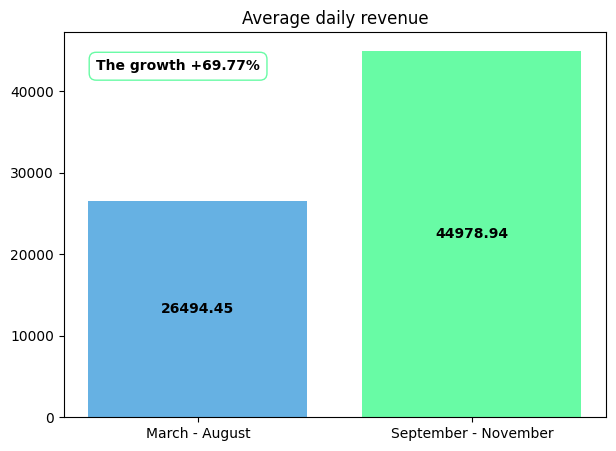

In [30]:
plt.figure(figsize=(7, 5))
revenue_difference = plt.bar(['March - August', 'September - November'], [group_jan_to_aug_mean, group_sep_to_nov_mean], color=['#3498dbc0', '#2dfa82b7'])

plt.bar_label(revenue_difference, label_type='center', fmt='%.2f', fontweight='bold') 
plt.text(
    0.06, 0.93,
    f'The growth +{actual_growth:.2f}%', 
    transform=plt.gca().transAxes,
    ha='left', va='top',
    fontweight='bold', color='black',
    bbox=dict(facecolor='white', edgecolor='#2dfa82b7', boxstyle='round,pad=0.5')
)
plt.title('Average daily revenue')
plt.show()

In [31]:
autumn = df[(df['InvoiceDate'].dt.month > 8) & (df['InvoiceDate'].dt.month < 12)]
autumn['Month'] = autumn['InvoiceDate'].dt.month
months = {9: 'September', 10: 'October', 11: 'November'}

for month_num, month_name in months.items():
    month_data = autumn[autumn['Month'] == month_num]
    top_products = month_data.groupby('Description')['Quantity'].sum().reset_index() # Сумма проданных товаров, с учетом возвратов. Считаю сумму, а не количество упоминаний, так как есть оптовые продажи, а в этом случае больше упоминаний != рост выручки от товара
    top_5 = top_products.sort_values(by='Quantity', ascending=False).head(5)
    
    styled_top_5 = top_5.style.pipe(lambda s: s.set_caption(f'<b>Top 5 products for {month_name}</b>')).hide(axis='index').set_table_styles([
                        {'selector': '.col0', 'props': [('width', '280px')]}, # Ширина для Description
                        {'selector': '.col1', 'props': [('width', '70px')]}  # Ширина для Quantity
                    ])
    
    display(styled_top_5)

Description,Quantity
JUMBO BAG RED RETROSPOT,4267
POPCORN HOLDER,4005
60 CAKE CASES VINTAGE CHRISTMAS,3711
WORLD WAR 2 GLIDERS ASSTD DESIGNS,3515
MINI PAINT SET VINTAGE,3337


Description,Quantity
WORLD WAR 2 GLIDERS ASSTD DESIGNS,8180
RABBIT NIGHT LIGHT,6319
POPCORN HOLDER,5865
JUMBO BAG RED RETROSPOT,4803
60 CAKE CASES VINTAGE CHRISTMAS,3778


Description,Quantity
RABBIT NIGHT LIGHT,14883
POPCORN HOLDER,12159
PAPER CHAIN KIT 50'S CHRISTMAS,7868
JUMBO BAG RED RETROSPOT,5807
WOODEN STAR CHRISTMAS SCANDINAVIAN,5365


In [32]:
spring_and_summer = df[(df['InvoiceDate'].dt.month >= 1) & (df['InvoiceDate'].dt.month <= 8)]
spring_and_summer['Month'] = spring_and_summer['InvoiceDate'].dt.month
months = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June', 7: 'July', 8: 'August'}

for month_num, month_name in months.items():
    month_data = spring_and_summer[spring_and_summer['Month'] == month_num]
    top_products = month_data.groupby('Description')['Quantity'].sum().reset_index() # Сумма проданных товаров, с учетом возвратов. Считаю сумму, а не количество упоминаний, так как есть оптовые продажи, а в этом случае больше упоминаний != рост выручки от товара
    top_5 = top_products.sort_values(by='Quantity', ascending=False).head(5)
    
    styled_top_5 = top_5.style.pipe(lambda s: s.set_caption(f'<b>Top 5 products for {month_name}</b>')).hide(axis='index').set_table_styles([
                        {'selector': '.col0', 'props': [('width', '280px')]}, # Ширина для Description
                        {'selector': '.col1', 'props': [('width', '70px')]}  # Ширина для Quantity
                    ])
    
    display(styled_top_5)

# С января по август рождественские товары не попадали в топ-5

Description,Quantity
WHITE HANGING HEART T-LIGHT HOLDER,5530
PACK OF 72 RETROSPOT CAKE CASES,3409
FAIRY CAKE FLANNEL ASSORTED COLOUR,3246
BROCADE RING PURSE,3181
HEART OF WICKER SMALL,2919


Description,Quantity
EMPIRE DESIGN ROSETTE,3986
GROW A FLYTRAP OR SUNFLOWER IN TIN,3795
WORLD WAR 2 GLIDERS ASSTD DESIGNS,3518
JUMBO BAG RED RETROSPOT,3078
PACK OF 12 LONDON TISSUES,2725


Description,Quantity
JUMBO BAG RED RETROSPOT,5279
PACK OF 72 RETROSPOT CAKE CASES,3975
WORLD WAR 2 GLIDERS ASSTD DESIGNS,3888
PACK OF 12 LONDON TISSUES,3645
BROCADE RING PURSE,3396


Description,Quantity
WORLD WAR 2 GLIDERS ASSTD DESIGNS,10143
PACK OF 72 RETROSPOT CAKE CASES,2972
BALLOON WATER BOMB PACK OF 35,2644
GROW A FLYTRAP OR SUNFLOWER IN TIN,2609
ASSORTED COLOUR BIRD ORNAMENT,2560


Description,Quantity
SMALL POPCORN HOLDER,6848
ASSORTED COLOURS SILK FAN,4684
PACK OF 60 PINK PAISLEY CAKE CASES,4055
WHITE HANGING HEART T-LIGHT HOLDER,4021
WORLD WAR 2 GLIDERS ASSTD DESIGNS,3893


Description,Quantity
JUMBO BAG RED RETROSPOT,3675
ASSORTED COLOURS SILK FAN,3346
BROCADE RING PURSE,2989
PACK OF 12 LONDON TISSUES,2429
COLOUR GLASS T-LIGHT HOLDER HANGING,2346


Description,Quantity
GIRLS ALPHABET IRON ON PATCHES,5019
WORLD WAR 2 GLIDERS ASSTD DESIGNS,3714
ASSORTED COLOURS SILK FAN,3390
ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3207
JUMBO BAG RED RETROSPOT,3126


Description,Quantity
ASSORTED COLOUR BIRD ORNAMENT,6552
JUMBO BAG RED RETROSPOT,5401
POPCORN HOLDER,5316
JUMBO BAG APPLES,3205
PACK OF 72 RETROSPOT CAKE CASES,3014
